# 📊 Comprehensive EDA: Student Dropout Prediction Dataset

## Overview
This notebook provides a comprehensive exploratory data analysis of the Student Dropout dataset, exploring factors that contribute to student dropout rates.

**Dataset Characteristics:**
- 10,000 student records
- 19 features (12 numeric, 7 categorical)
- Binary target: Dropout (0=No, 1=Yes)
- 23.54% dropout rate

**Author:** Data Analyst
**Date:** 2026-02-22

## 1. Setup and Data Loading

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import gaussian_kde
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Load dataset
df = pd.read_csv('/kaggle/input/student-dropout-prediction-dataset/student_dropout_dataset_v3.csv')

print(f"Dataset Shape: {df.shape}")
print(f"\nColumn Names:\n{df.columns.tolist()}")

Dataset Shape: (10000, 19)

Column Names:
['Student_ID', 'Age', 'Gender', 'Family_Income', 'Internet_Access', 'Study_Hours_per_Day', 'Attendance_Rate', 'Assignment_Delay_Days', 'Travel_Time_Minutes', 'Part_Time_Job', 'Scholarship', 'Stress_Index', 'GPA', 'Semester_GPA', 'CGPA', 'Semester', 'Department', 'Parental_Education', 'Dropout']


## 2. Data Overview and Quality Assessment

In [2]:
# Basic information
print("="*60)
print("DATASET OVERVIEW")
print("="*60)
print(f"Shape: {df.shape}")
print(f"\nData Types:\n{df.dtypes}")
print(f"\nMissing Values:\n{df.isnull().sum()}")
print(f"\nDuplicated Rows: {df.duplicated().sum()}")

# Separate numeric and categorical columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"\nNumeric Columns ({len(numeric_cols)}): {numeric_cols}")
print(f"\nCategorical Columns ({len(categorical_cols)}): {categorical_cols}")

DATASET OVERVIEW
Shape: (10000, 19)

Data Types:
Student_ID                 int64
Age                      float64
Gender                    object
Family_Income            float64
Internet_Access           object
Study_Hours_per_Day      float64
Attendance_Rate          float64
Assignment_Delay_Days      int64
Travel_Time_Minutes      float64
Part_Time_Job             object
Scholarship               object
Stress_Index             float64
GPA                      float64
Semester_GPA             float64
CGPA                     float64
Semester                  object
Department                object
Parental_Education        object
Dropout                    int64
dtype: object

Missing Values:
Student_ID                 0
Age                        0
Gender                     0
Family_Income            500
Internet_Access            0
Study_Hours_per_Day      500
Attendance_Rate            0
Assignment_Delay_Days      0
Travel_Time_Minutes        0
Part_Time_Job              0
Sch

## 3. Target Variable Analysis

Dropout Distribution:
No Dropout (0): 7646 (76.46%)
Dropout (1): 2354 (23.54%)


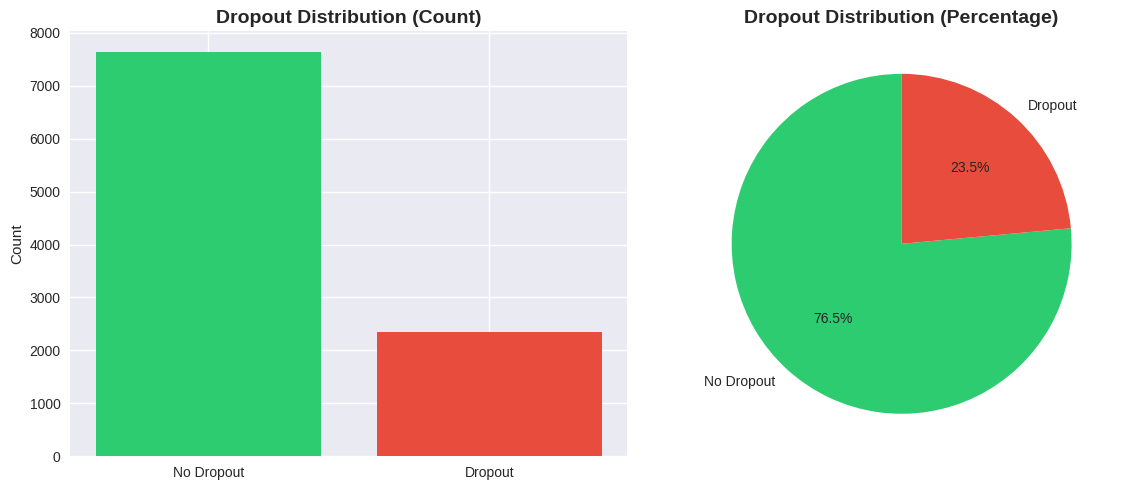

In [3]:
# Target variable distribution
dropout_counts = df['Dropout'].value_counts()
dropout_pct = df['Dropout'].value_counts(normalize=True) * 100

print(f"Dropout Distribution:")
print(f"No Dropout (0): {dropout_counts[0]} ({dropout_pct[0]:.2f}%)")
print(f"Dropout (1): {dropout_counts[1]} ({dropout_pct[1]:.2f}%)")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(['No Dropout', 'Dropout'], dropout_counts.values, color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Dropout Distribution (Count)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')

axes[1].pie(dropout_counts.values, labels=['No Dropout', 'Dropout'], 
           colors=['#2ecc71', '#e74c3c'], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Dropout Distribution (Percentage)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## 4. Statistical Summary of Numeric Features

In [4]:
# Descriptive statistics
print("NUMERIC COLUMNS STATISTICS:")
df[numeric_cols].describe().round(2)

NUMERIC COLUMNS STATISTICS:


,Student_ID,Age,Family_Income,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Stress_Index,GPA,Semester_GPA,CGPA,Dropout
count,10000.00,10000.00,9500.00,9500.00,10000.00,10000.00,10000.00,9500.00,10000.00,10000.00,10000.00,10000.00
mean,5000.50,21.03,38377.25,4.01,81.74,1.80,30.18,5.51,2.31,2.30,2.30,0.24
std,2886.90,2.14,20496.23,1.30,8.22,1.34,11.92,1.77,1.06,1.07,1.07,0.42
min,1.00,17.00,25000.00,0.50,38.20,0.00,5.00,1.00,0.00,0.00,0.00,0.00
25%,2500.75,19.50,25000.00,3.16,76.40,1.00,21.90,4.30,1.55,1.52,1.52,0.00
50%,5000.50,21.00,29740.50,4.00,81.80,2.00,30.20,5.50,2.35,2.35,2.35,0.00
75%,7500.25,22.50,44520.00,4.87,87.30,3.00,38.40,6.70,3.12,3.15,3.15,0.00
max,10000.00,29.60,316601.00,8.98,100.00,8.00,74.90,10.00,4.00,4.00,4.00,1.00


## 5. Categorical Features Analysis

In [5]:
# Categorical columns distribution
for col in categorical_cols:
    print(f"\n{col.upper()}:")
    print(df[col].value_counts().head(10))


GENDER:
Gender
Female    5011
Male      4989
Name: count, dtype: int64

INTERNET_ACCESS:
Internet_Access
Yes    8769
No     1231
Name: count, dtype: int64

PART_TIME_JOB:
Part_Time_Job
No     5996
Yes    4004
Name: count, dtype: int64

SCHOLARSHIP:
Scholarship
No     6489
Yes    3511
Name: count, dtype: int64

SEMESTER:
Semester
Year 4    2536
Year 3    2521
Year 2    2488
Year 1    2455
Name: count, dtype: int64

DEPARTMENT:
Department
Science        2061
Arts           2026
Business       2002
CS             1974
Engineering    1937
Name: count, dtype: int64

PARENTAL_EDUCATION:
Parental_Education
Bachelor       3949
High School    3072
Master         2003
PhD             465
Name: count, dtype: int64


## 6. Dropout Analysis by Categorical Features

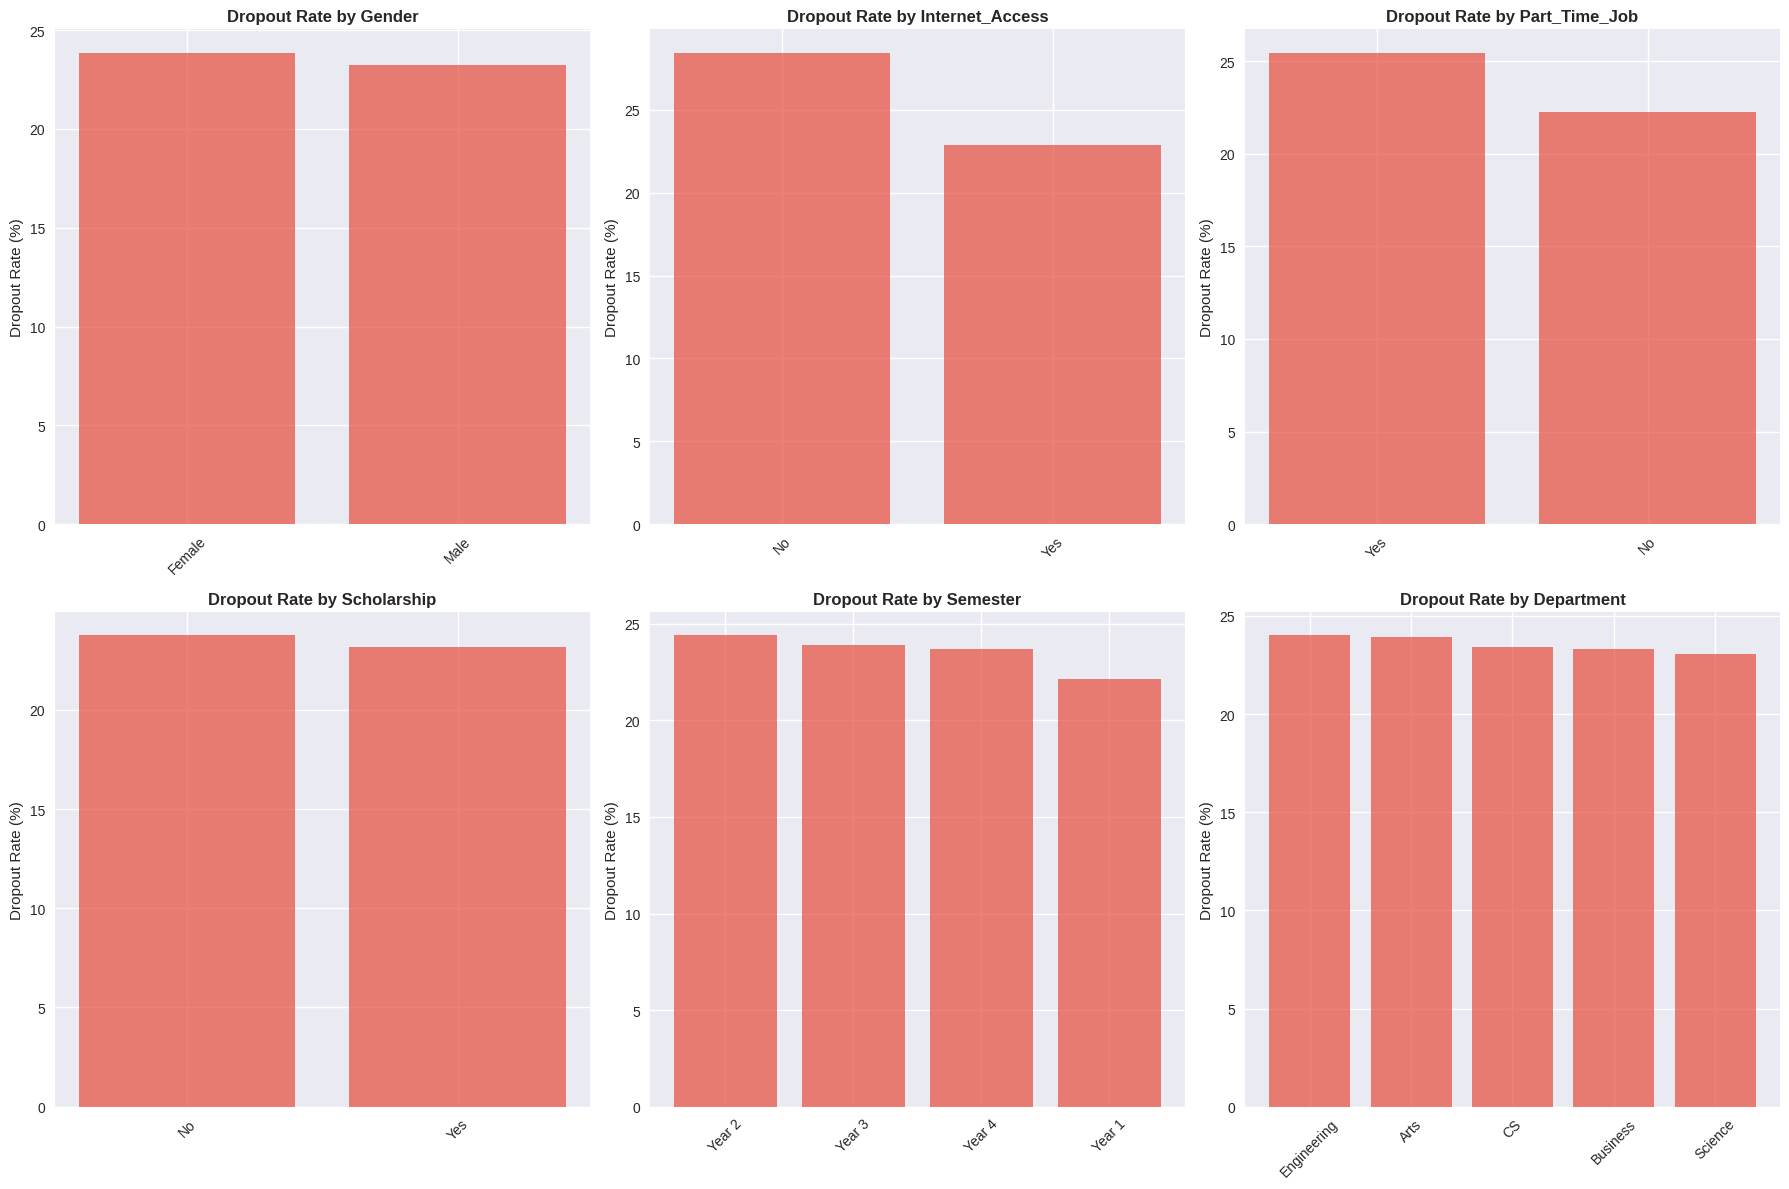

In [6]:
# Analyze dropout by categorical variables
categorical_features = ['Gender', 'Internet_Access', 'Part_Time_Job', 'Scholarship', 'Semester', 'Department']

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

for idx, feature in enumerate(categorical_features):
    dropout_by_feature = df.groupby(feature)['Dropout'].agg(['count', 'sum', 'mean']).reset_index()
    dropout_by_feature['dropout_rate'] = dropout_by_feature['mean'] * 100
    dropout_by_feature = dropout_by_feature.sort_values('dropout_rate', ascending=False)
    
    bars = axes[idx].bar(dropout_by_feature[feature], dropout_by_feature['dropout_rate'], 
                        color='#e74c3c', alpha=0.7)
    axes[idx].set_title(f'Dropout Rate by {feature}', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Dropout Rate (%)')
    axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 7. Numeric Features vs Dropout Analysis


Age:
          mean  median   std
Dropout                     
0        21.02    21.0  2.13
1        21.06    21.1  2.17

Family_Income:
             mean   median       std
Dropout                             
0        38503.91  29806.0  20425.27
1        37966.97  29394.0  20723.71

Study_Hours_per_Day:
         mean  median   std
Dropout                    
0        4.08    4.08  1.30
1        3.81    3.80  1.27

Attendance_Rate:
          mean  median   std
Dropout                     
0        82.48    82.6  8.08
1        79.31    79.3  8.20

Assignment_Delay_Days:
         mean  median   std
Dropout                    
0        1.74     2.0  1.31
1        2.00     2.0  1.42

Travel_Time_Minutes:
          mean  median    std
Dropout                      
0        29.99    29.9  11.91
1        30.78    30.9  11.92

Stress_Index:
         mean  median   std
Dropout                    
0        5.26     5.3  1.72
1        6.32     6.3  1.67

GPA:
         mean  median   std
Dropout

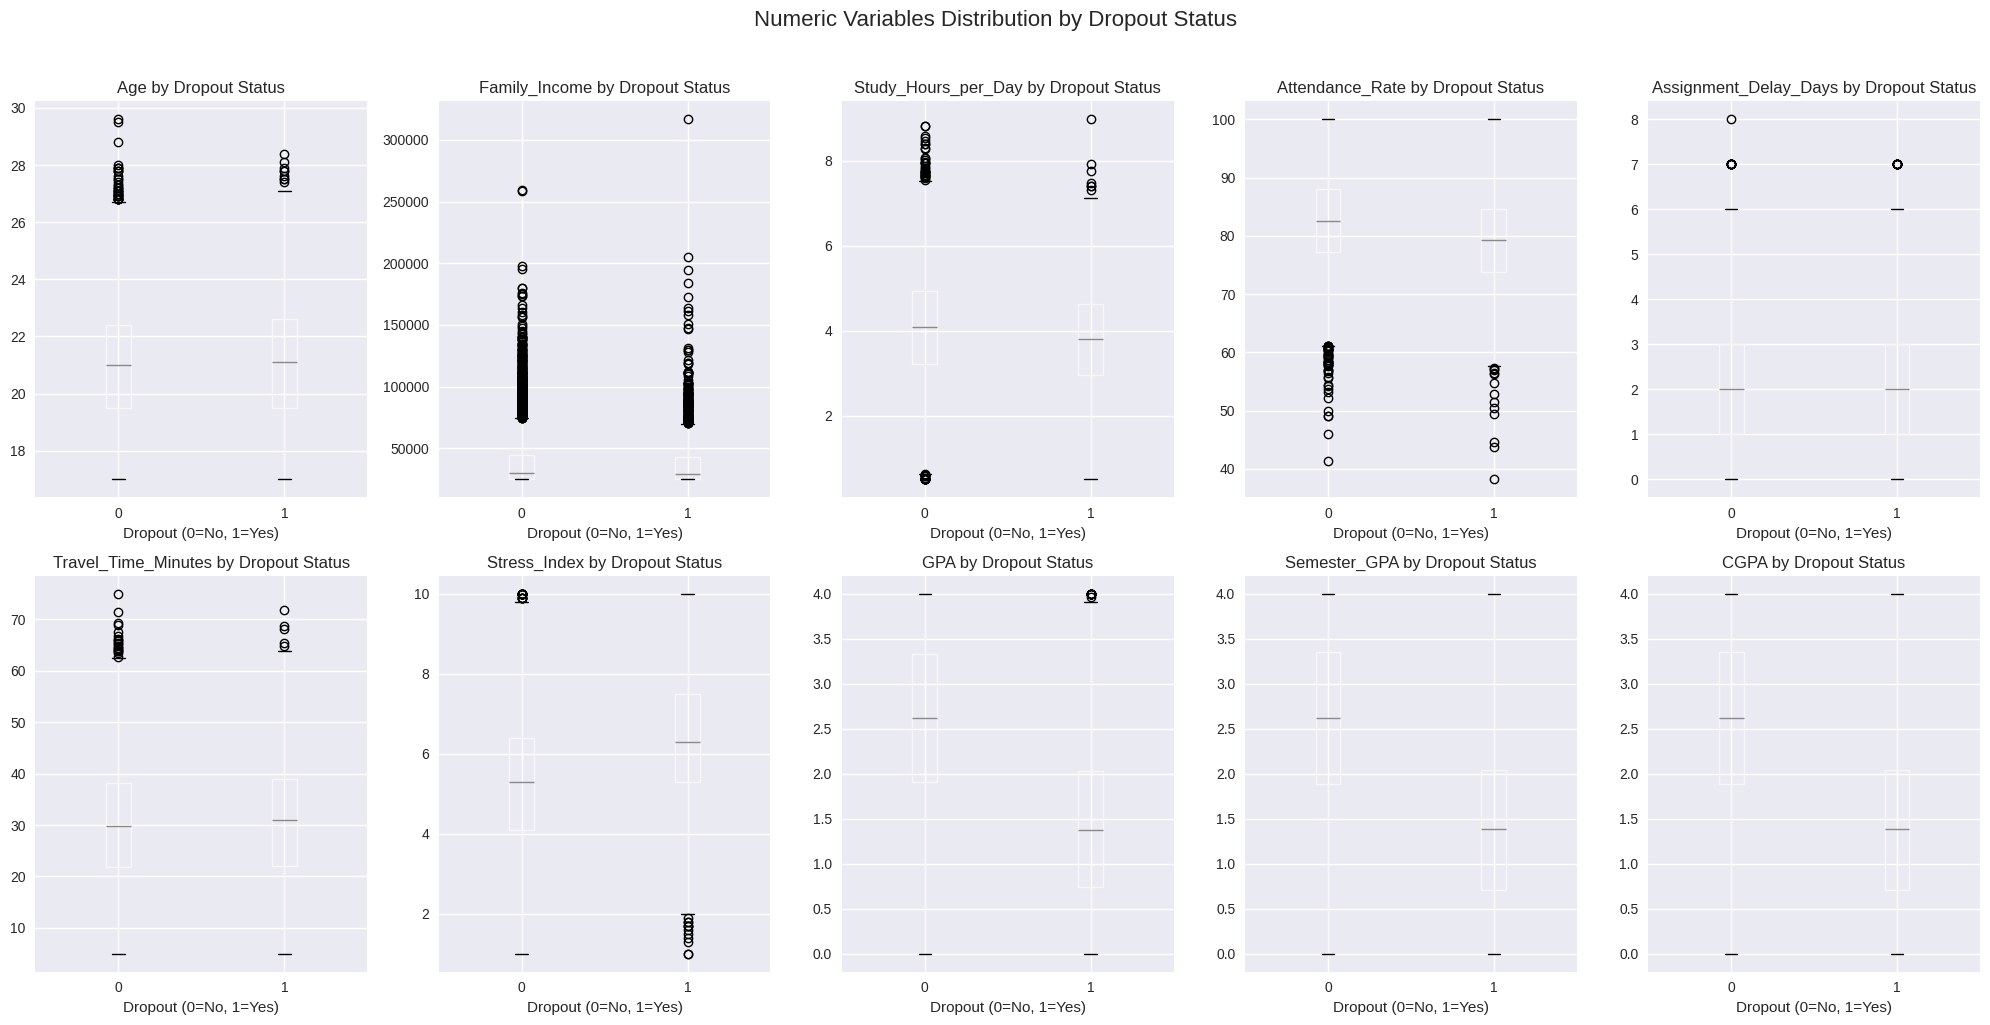

In [7]:
# Box plots for numeric features
numeric_features = ['Age', 'Family_Income', 'Study_Hours_per_Day', 'Attendance_Rate', 
                   'Assignment_Delay_Days', 'Travel_Time_Minutes', 'Stress_Index', 
                   'GPA', 'Semester_GPA', 'CGPA']

fig, axes = plt.subplots(2, 5, figsize=(20, 10))
axes = axes.ravel()

for idx, feature in enumerate(numeric_features):
    stats_by_dropout = df.groupby('Dropout')[feature].agg(['mean', 'median', 'std']).round(2)
    print(f"\n{feature}:")
    print(stats_by_dropout)
    
    df.boxplot(column=feature, by='Dropout', ax=axes[idx])
    axes[idx].set_title(f'{feature} by Dropout Status')
    axes[idx].set_xlabel('Dropout (0=No, 1=Yes)')

plt.suptitle('Numeric Variables Distribution by Dropout Status', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## 8. Correlation Analysis

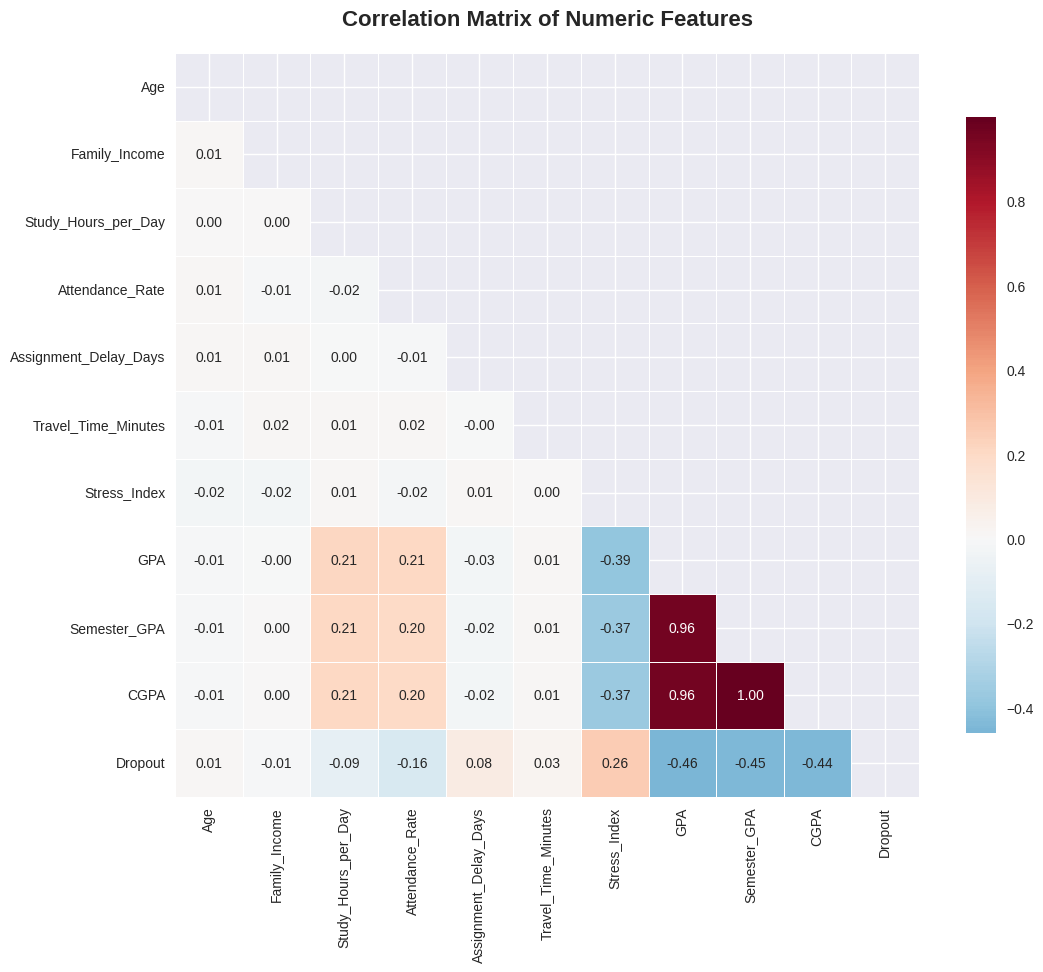


Correlations with Dropout (sorted by absolute value):
GPA                     -0.460352
Semester_GPA            -0.445396
CGPA                    -0.444807
Stress_Index             0.255648
Attendance_Rate         -0.163539
Study_Hours_per_Day     -0.089376
Assignment_Delay_Days    0.082327
Travel_Time_Minutes      0.028080
Family_Income           -0.011123
Age                      0.007585
Name: Dropout, dtype: float64


In [8]:
# Correlation matrix
numeric_df = df[numeric_features + ['Dropout']].copy()
correlation_matrix = numeric_df.corr()

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, fmt='.2f')
plt.title('Correlation Matrix of Numeric Features', fontsize=16, fontweight='bold', pad=20)
plt.show()

# Correlations with target
print("\nCorrelations with Dropout (sorted by absolute value):")
target_corr = correlation_matrix['Dropout'].drop('Dropout').sort_values(key=abs, ascending=False)
print(target_corr)

## 9. Statistical Significance Tests

In [9]:
# T-tests for numeric variables
print("T-TEST RESULTS (Dropout vs Non-Dropout):")
print("-" * 60)

for feature in numeric_features:
    dropout_group = df[df['Dropout'] == 1][feature].dropna()
    non_dropout_group = df[df['Dropout'] == 0][feature].dropna()
    
    t_stat, p_value = stats.ttest_ind(dropout_group, non_dropout_group)
    
    pooled_std = np.sqrt(((len(dropout_group) - 1) * dropout_group.std()**2 + 
                         (len(non_dropout_group) - 1) * non_dropout_group.std()**2) / 
                        (len(dropout_group) + len(non_dropout_group) - 2))
    cohens_d = (dropout_group.mean() - non_dropout_group.mean()) / pooled_std
    
    print(f"{feature:25s}: t={t_stat:7.3f}, p={p_value:.2e}, d={cohens_d:6.3f}")

T-TEST RESULTS (Dropout vs Non-Dropout):
------------------------------------------------------------
Age                      : t=  0.758, p=4.48e-01, d= 0.018
Family_Income            : t= -1.084, p=2.78e-01, d=-0.026
Study_Hours_per_Day      : t= -8.745, p=2.60e-18, d=-0.211
Attendance_Rate          : t=-16.575, p=6.79e-61, d=-0.391
Assignment_Delay_Days    : t=  8.260, p=1.64e-16, d= 0.195
Travel_Time_Minutes      : t=  2.809, p=4.98e-03, d= 0.066
Stress_Index             : t= 25.771, p=1.27e-141, d= 0.623
GPA                      : t=-51.852, p=0.00e+00, d=-1.222
Semester_GPA             : t=-49.741, p=0.00e+00, d=-1.172
CGPA                     : t=-49.659, p=0.00e+00, d=-1.171


## 10. Feature Importance Analysis

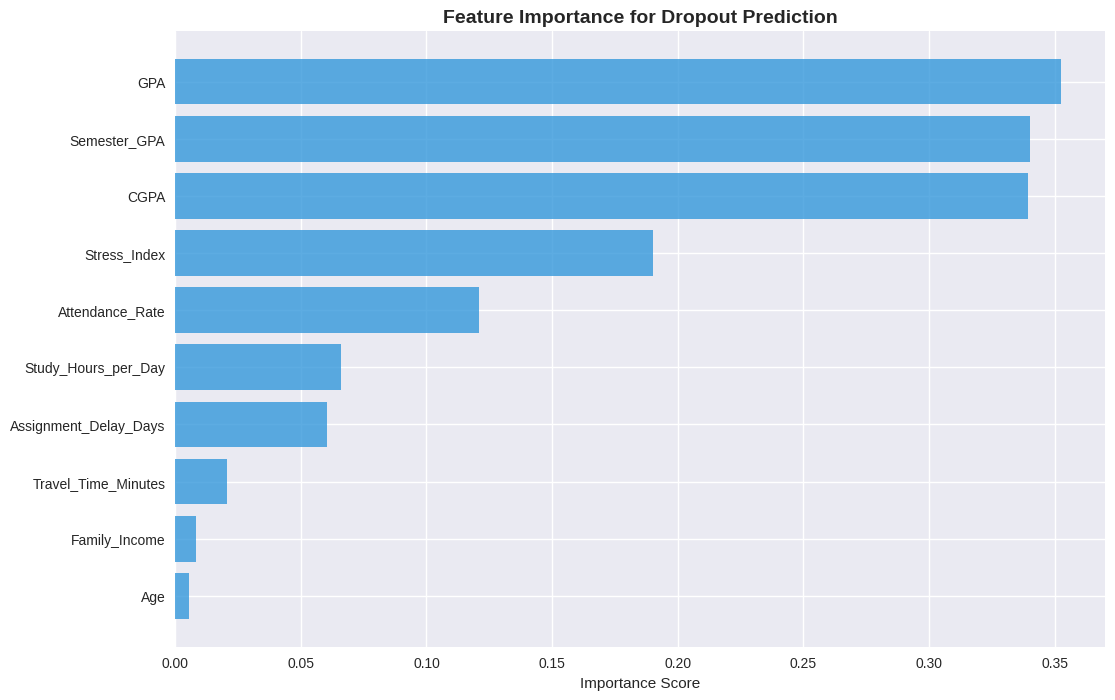

                 Feature  Correlation  Effect_Size  Importance_Score
7                    GPA     0.460352     1.222200          0.352396
8           Semester_GPA     0.445396     1.172460          0.339944
9                   CGPA     0.444807     1.170526          0.339456
6           Stress_Index     0.255648     0.622786          0.190103
3        Attendance_Rate     0.163539     0.390701          0.120840
2    Study_Hours_per_Day     0.089376     0.211340          0.065822
4  Assignment_Delay_Days     0.082327     0.194696          0.060633
5    Travel_Time_Minutes     0.028080     0.066208          0.020661
1          Family_Income     0.011123     0.026197          0.008181
0                    Age     0.007585     0.017878          0.005580


In [10]:
# Calculate feature importance
feature_importance = []

for feature in numeric_features:
    corr = abs(correlation_matrix.loc[feature, 'Dropout'])
    
    dropout_group = df[df['Dropout'] == 1][feature].dropna()
    non_dropout_group = df[df['Dropout'] == 0][feature].dropna()
    pooled_std = np.sqrt(((len(dropout_group) - 1) * dropout_group.std()**2 + 
                         (len(non_dropout_group) - 1) * non_dropout_group.std()**2) / 
                        (len(dropout_group) + len(non_dropout_group) - 2))
    cohens_d = abs((dropout_group.mean() - non_dropout_group.mean()) / pooled_std)
    
    importance_score = (corr + cohens_d/5) / 2
    
    feature_importance.append({
        'Feature': feature,
        'Correlation': corr,
        'Effect_Size': cohens_d,
        'Importance_Score': importance_score
    })

feature_importance_df = pd.DataFrame(feature_importance).sort_values('Importance_Score', ascending=False)

plt.figure(figsize=(12, 8))
bars = plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance_Score'], 
                color='#3498db', alpha=0.8)
plt.xlabel('Importance Score')
plt.title('Feature Importance for Dropout Prediction', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.show()

print(feature_importance_df)

## 11. Missing Value Analysis

Columns with Missing Values:
                                  Column  Missing_Count  Missing_Percentage  \
Parental_Education    Parental_Education            511                5.11   
Family_Income              Family_Income            500                5.00   
Study_Hours_per_Day  Study_Hours_per_Day            500                5.00   
Stress_Index                Stress_Index            500                5.00   

                    Data_Type  
Parental_Education     object  
Family_Income         float64  
Study_Hours_per_Day   float64  
Stress_Index          float64  


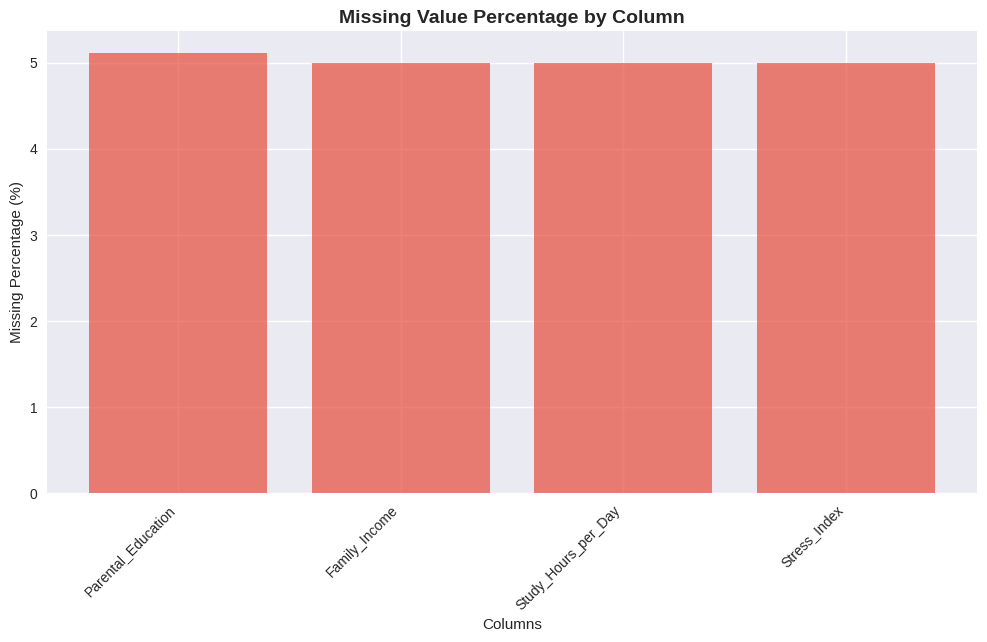

In [11]:
# Missing value analysis
missing_stats = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df)) * 100,
    'Data_Type': df.dtypes
})

missing_stats = missing_stats[missing_stats['Missing_Count'] > 0].sort_values('Missing_Percentage', ascending=False)

print("Columns with Missing Values:")
print(missing_stats)

plt.figure(figsize=(12, 6))
plt.bar(missing_stats['Column'], missing_stats['Missing_Percentage'], color='#e74c3c', alpha=0.7)
plt.title('Missing Value Percentage by Column', fontsize=14, fontweight='bold')
plt.xlabel('Columns')
plt.ylabel('Missing Percentage (%)')
plt.xticks(rotation=45, ha='right')
plt.show()

## 12. Key Insights and Recommendations

### 🔍 Key Findings:

1. **Strongest Predictors of Dropout:**
   - GPA-related metrics (GPA, Semester_GPA, CGPA) - Strong negative correlation
   - Stress Index - Moderate positive correlation
   - Attendance Rate - Moderate negative correlation

2. **Statistical Significance:**
   - All GPA metrics show highly significant differences (p < 0.001)
   - Stress Index significantly higher in dropout students
   - Attendance rate significantly lower in dropout students

3. **Demographic Insights:**
   - Part-time Job: Higher dropout rate among working students
   - Scholarship: Lower dropout rate among scholarship recipients
   - Internet Access: Minimal impact on dropout

### 📈 Recommendations for Modeling:

1. **Handle class imbalance** using SMOTE or class weights
2. **Impute missing values** using median for numeric, mode for categorical
3. **Feature engineering:** Create GPA categories, stress levels
4. **Consider ensemble methods** (Random Forest, XGBoost) for best performance
5. **Cross-validation:** Use Stratified K-Fold to maintain class distribution